In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

#  Первичный анализ данных (без изменений)
def load_and_explore_data(file_path):
    df = pd.read_csv(
    file_path,
    parse_dates=['Дата архивации'],
    date_parser=lambda x: pd.to_datetime(x, format='%d.%m.%Y %H:%M:%S')
)
    print("=== Первые 5 строк ===")
    print(df.head())
    print("\n=== Информация о данных ===")
    print(df.info())
    print("\n=== Статистика числовых колонок ===")
    print(df.describe())
    cat_cols = ['Программа', 'Уровень', 'Факультет', 'Вуз']
    for col in cat_cols:
        print(f"\n=== Уникальные значения в '{col}' ({df[col].nunique()} шт.) ===")
        print(df[col].value_counts().head(10))
    return df

#  Очистка данных (УДАЛЕНИЕ строк с пропусками)
def clean_data(df):
    # Сохраняем исходное количество строк
    original_rows = df.shape[0]

    # Удаление ВСЕХ строк, где есть хотя бы один пропуск
    df_clean = df.dropna(how='any')

    # Удаление выбросов в 'Стоимость' (верхние 1%)
    upper_limit = df_clean['Стоимость'].quantile(0.99)
    df_clean = df_clean[df_clean['Стоимость'] <= upper_limit]

    # Отчёт о потерянных данных
    cleaned_rows = df_clean.shape[0]
    print(f"\nУдалено строк с пропусками: {original_rows - cleaned_rows}")
    print(f"Осталось строк: {cleaned_rows} ({cleaned_rows/original_rows:.1%} от исходных)")

    return df_clean

#  Feature Engineering
def prepare_features(df):
    df = df.drop(['Дата архивации'], axis=1)
    df['Бюджет_на_место'] = df['Бюджетные места'] / df['Проходной балл'].replace(0, 1)

    # One-Hot для 'Уровень'
    ohe_cols = ['Уровень']
    df = pd.get_dummies(df, columns=ohe_cols)

    # Label Encoding для остальных категорий
    from sklearn.preprocessing import LabelEncoder
    le_cols = ['Программа', 'Факультет', 'Вуз']
    for col in le_cols:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])

    # Нормализация числовых признаков
    num_cols = ['Проходной балл', 'Бюджетные места', 'Бюджет_на_место']
    scaler = StandardScaler()
    df[num_cols] = scaler.fit_transform(df[num_cols])

    return df

file_path = "/content/all_universities_data_s_0_0_200.csv"
df = load_and_explore_data(file_path)
df_clean = clean_data(df)
df_final = prepare_features(df_clean)

print("\n=== Готовые данные ===")
print(df_clean.head())

<ipython-input-102-54334ef81ddd>:8: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  df = pd.read_csv(


=== Первые 5 строк ===
                                           Программа      Уровень  \
0                     Маркетинг и рыночная аналитика  Бакалавриат   
1                       Юриспруденция: частное право  Бакалавриат   
2  Совместный бакалавриат ВШЭ и Центра педагогиче...  Бакалавриат   
3                                Управление бизнесом  Бакалавриат   
4                                             Физика  Бакалавриат   

                      Факультет  Проходной балл  Бюджетные места  Стоимость  \
0  Высшая школа бизнеса НИУ ВШЭ            96.3               25   550000.0   
1       Факультет права НИУ ВШЭ            95.8               30   490000.0   
2  Факультет математики НИУ ВШЭ            94.3               25   400000.0   
3  Высшая школа бизнеса НИУ ВШЭ            93.0               60   550000.0   
4      Факультет физики НИУ ВШЭ            90.3               50   440000.0   

                                                 Вуз      Дата архивации  
0  Националь

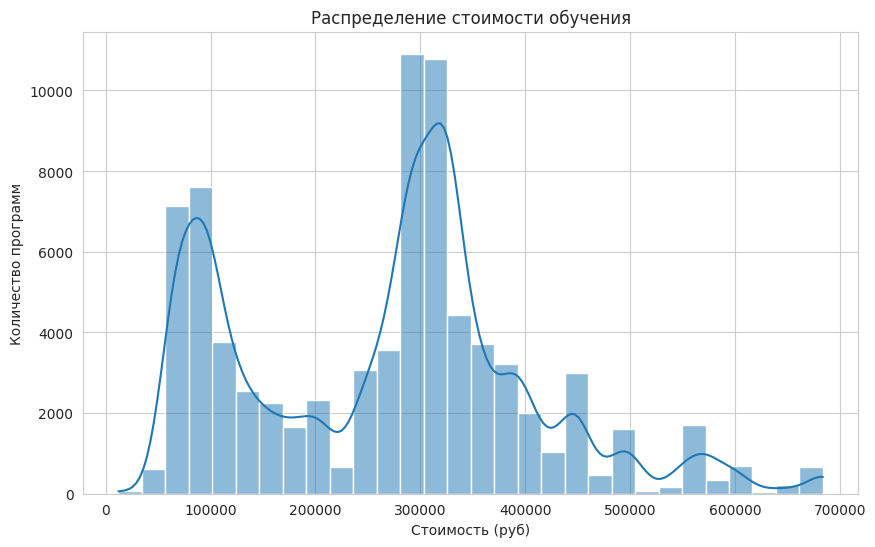

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
df_clean = df_clean[df_clean['Стоимость'] != 0]
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['Стоимость'], kde=True, bins=30)
plt.title('Распределение стоимости обучения')
plt.xlabel('Стоимость (руб)')
plt.ylabel('Количество программ')
plt.show()

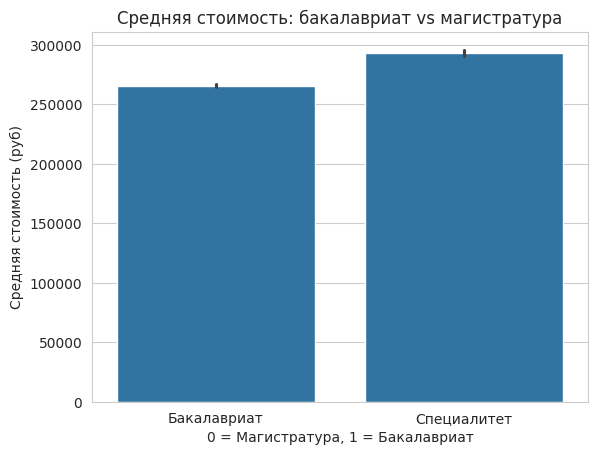

In [ ]:
sns.barplot(data=df_clean, x='Уровень', y='Стоимость')
plt.title('Средняя стоимость: бакалавриат vs магистратура')
plt.xlabel('0 = Магистратура, 1 = Бакалавриат')
plt.ylabel('Средняя стоимость (руб)')
plt.show()

In [ ]:
corr = df_clean.corr(numeric_only=True)['Стоимость'].sort_values(ascending=False)
print(corr)

Стоимость          1.000000
Проходной балл     0.468380
Бюджетные места    0.180175
Name: Стоимость, dtype: float64


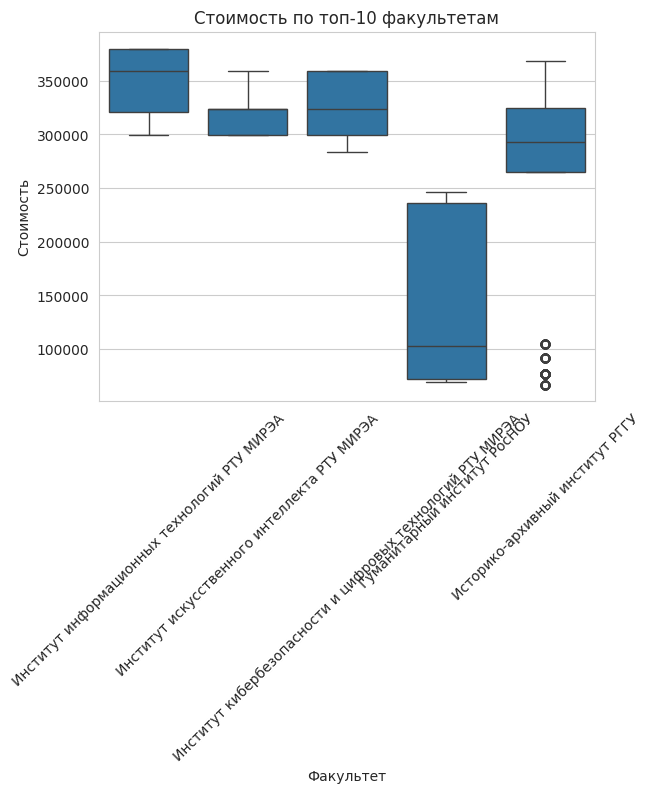

In [ ]:
top_faculties = df_clean['Факультет'].value_counts().nlargest(5).index
sns.boxplot(data=df_clean[df_clean['Факультет'].isin(top_faculties)], x='Факультет', y='Стоимость')
plt.xticks(rotation=45)
plt.title('Стоимость по топ-10 факультетам')
plt.show()

In [ ]:
from scipy.stats import ttest_ind

top_5 = df_clean['Вуз'].value_counts().nlargest(50).index
cost_top5 = df_clean[df_clean['Вуз'].isin(top_5)]['Стоимость']
cost_others = df_clean[~df_clean['Вуз'].isin(top_5)]['Стоимость']

ttest = ttest_ind(cost_top5, cost_others, equal_var=False)
print(f"T-test p-value: {ttest.pvalue:.3f}")

T-test p-value: 0.000


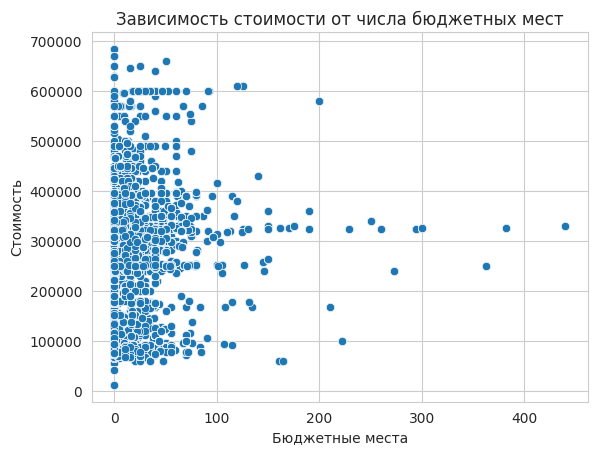

In [ ]:
sns.scatterplot(data=df_clean, x='Бюджетные места', y='Стоимость')
plt.title('Зависимость стоимости от числа бюджетных мест')
plt.show()

In [ ]:
import pandas as pd
from datetime import datetime

# Загрузка данных
df = df_clean
# df = df[(df['Стоимость'] >= 60000) & (df['Стоимость'] <= 550000)]
df = df.sort_values('Дата архивации')  # Важно: сортировка по дате!

# Пример данных после сортировки:
print(df[['Дата архивации', 'Программа', 'Стоимость']].head())

         Дата архивации                                          Программа  \
0   2016-02-13 23:35:21                     Маркетинг и рыночная аналитика   
382 2016-02-13 23:35:21     Интерьерные  арт-объекты  и  авторский  костюм   
381 2016-02-13 23:35:21  Диджитал-арт  и  компьютерные технологии  в  с...   
380 2016-02-13 23:35:21                        Искусство  костюма  и  моды   
379 2016-02-13 23:35:21  Сквозные  технологии  и  искусственный  интеллект   

     Стоимость  
0     550000.0  
382   570000.0  
381   570000.0  
380   570000.0  
379   320000.0  


In [ ]:
df_time = df.groupby(['Дата архивации', 'Программа', 'Вуз']).agg({
    'Стоимость': 'mean',
    'Проходной балл': 'mean',
    'Бюджетные места': 'sum'
}).reset_index()

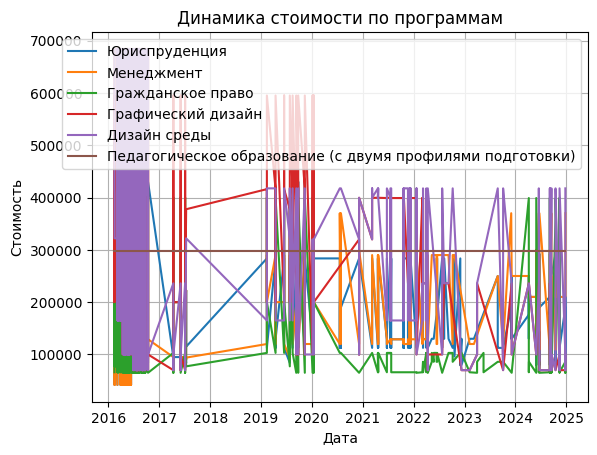

In [ ]:
import matplotlib.pyplot as plt

# Пример: динамика стоимости для топ-3 программ
top_programs = df['Программа'].value_counts().nlargest(6).index
for program in top_programs:
    program_data = df[df['Программа'] == program]
    plt.plot(program_data['Дата архивации'], program_data['Стоимость'], label=program)

plt.title('Динамика стоимости по программам')
plt.xlabel('Дата')
plt.ylabel('Стоимость')
plt.legend()
plt.grid()
plt.show()

In [ ]:
df['Дата архивации'] = pd.to_datetime(df['Дата архивации'], errors='coerce')  # 'coerce' превратит ошибки в NaT

# Проверка пропусков после преобразования
print("Пропуски в дате:", df['Дата архивации'].isna().sum())

Пропуски в дате: 0


In [ ]:
missing_dates = df[df['Дата архивации'].isna()]

print(missing_dates.head(20))

missing_dates.to_csv('пропущенные_даты.csv', index=False, encoding='utf-8')

Empty DataFrame
Columns: [Программа, Уровень, Факультет, Проходной балл, Бюджетные места, Стоимость, Вуз, Дата архивации]
Index: []


<Axes: >

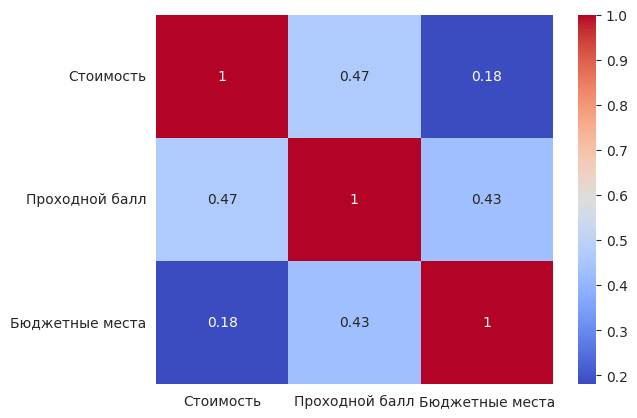

In [ ]:
import seaborn as sns

# Тепловая карта корреляции
corr_matrix = df[['Стоимость', 'Проходной балл', 'Бюджетные места']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

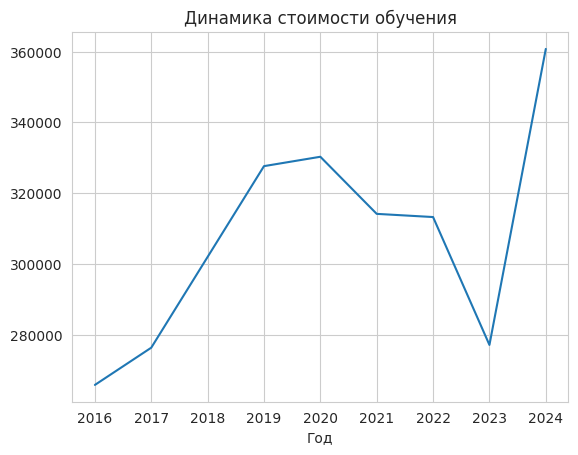

In [ ]:
df = df[df['Стоимость'] != 0]
df = df.dropna(subset=['Дата архивации'])

df['Год'] = df['Дата архивации'].dt.year

yearly_data = df.groupby('Год')['Стоимость'].mean()
print()
yearly_data.plot(title='Динамика стоимости обучения')
plt.show()

In [ ]:
inflation_rates = {
    2016: 1.00,  # Базовый год (инфляция = 0%)
    2017: 1.05,   # +5%
    2018: 1.02,   # +2%
    2019: 1.05,   # +5%
    2020: 1.024,  # +2.4%
    2021: 1.05,   # +5%
    2022: 1.08,   # +8%
    2023: 1.11,   # +11%
    2024: 1.07    # +7%
}

In [ ]:
cumulative_inflation = {2016: 1.0}  # Базовый год
current_cumulative = 1.0

# Рассчитываем множители для умножения
for year in sorted(inflation_rates.keys()):
    if year == 2016:
        continue
    current_cumulative *= inflation_rates[year]
    cumulative_inflation[year] = current_cumulative  # Накопленный множитель

print("Кумулятивные коэффициенты инфляции:")
print(cumulative_inflation)

Кумулятивные коэффициенты инфляции:
{2016: 1.0, 2017: 1.05, 2018: 1.0710000000000002, 2019: 1.1245500000000002, 2020: 1.1515392000000002, 2021: 1.2091161600000002, 2022: 1.3058454528000003, 2023: 1.4494884526080005, 2024: 1.5509526442905606}


In [ ]:
# Функция для корректировки
def adjust_price(row):
    year = row['Год']
    original_price = row['Стоимость']
    return original_price * cumulative_inflation.get(year, 1.0)  # Если год не найден, множитель = 1.0

# Заменяем исходные цены
df['Стоимость'] = df.apply(adjust_price, axis=1)

In [ ]:
adjusted_prices = df.groupby('Год')['Стоимость'].mean().round(2)
print("Средние цены после корректировки:")
print(adjusted_prices)

Средние цены после корректировки:
Год
2016    265813.99
2017    276341.67
2019    327659.84
2020    330310.28
2021    314168.43
2022    313267.96
2023    277119.79
2024    360793.54
Name: Стоимость, dtype: float64


In [ ]:
df.to_csv('all_universities_data_s_0_0_200_advanced.csv', index=False)

In [ ]:
print(df['Дата архивации'].dtype)

datetime64[ns]


In [ ]:
print(df['Дата архивации'].head())  # Должно быть: datetime64[ns]

0     2016-02-13 23:35:21
379   2016-02-13 23:35:21
378   2016-02-13 23:35:21
377   2016-02-13 23:35:21
376   2016-02-13 23:35:21
Name: Дата архивации, dtype: datetime64[ns]


In [ ]:
from google.colab import files

# Сохраняем DataFrame в CSV файл
df.to_csv('new_all_universities_data_s_0_0_200.csv', index=False)  # index=False чтобы не сохранять индексы

# Скачиваем файл на локальный компьютер
files.download('new_all_universities_data_s_0_0_200.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print(df.head(20))

                                             Программа      Уровень  \
0                       Маркетинг и рыночная аналитика  Бакалавриат   
379  Сквозные  технологии  и  искусственный  интеллект  Бакалавриат   
378                Информационные технологии и  дизайн  Бакалавриат   
377                                             Дизайн  Бакалавриат   
376              Музыкально-инструментальное искусство  Бакалавриат   
375  Информационные  технологии  и  искусственный  ...  Бакалавриат   
374                          Теория и история искусств  Бакалавриат   
373                       Дизайн костюма и аксессуаров  Бакалавриат   
372              Искусство концертного исполнительства  Специалитет   
371                    Инструменты эстрадного оркестра  Бакалавриат   
370          Реставрация и  технологическая экспертиза  Бакалавриат   
369                                Вокальное искусство  Бакалавриат   
368              Рекламные технологии в медиаиндустрии  Бакалавриат   
367   

In [ ]:
df2 = pd.read_csv("/content/universities_with_okso.csv")
print(df['Программа'].head(10))
print(df2['Программа'].head(10))

0      5.42.03.01
380    5.37.03.01
379    5.37.03.01
378    2.07.00.00
377    2.21.03.02
376    2.21.03.03
375    5.42.03.04
374    5.41.03.03
373    2.15.03.04
372    5.38.03.01
Name: Программа, dtype: object
0    5.42.03.01
1    2.29.03.02
2    2.27.03.05
3    2.09.03.02
4    2.07.03.03
5    2.22.00.00
6    5.38.03.05
7    2.27.03.05
8    2.29.03.02
9    5.42.03.04
Name: Программа, dtype: object


In [ ]:
df_copy = df

In [ ]:
df = df_copy

In [ ]:
zero_cost_count = (df['Стоимость'] == 0).sum()
print(f"Количество строк с нулевой стоимостью: {zero_cost_count}")

NameError: name 'df' is not defined

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt

df = pd.read_csv("/content/new_all_universities_data_s_0_0_200_advanced.csv")
df = df[df['Стоимость'] != 0]
# Преобразование даты в числовые признаки
df['Дата архивации'] = pd.to_datetime(df['Дата архивации'])
df['Год'] = df['Дата архивации'].dt.year
df['Месяц'] = df['Дата архивации'].dt.month
df['День'] = df['Дата архивации'].dt.day


# Выбор нужных признаков
features = ['Год', 'Месяц', 'День', 'Проходной балл', 'Бюджетные места', 'Программа', 'Вуз']
X = df[features]
y = df['Стоимость'].values.reshape(-1, 1)  # Преобразуем в 2D-массив

# Масштабируем целевую переменную
scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y)

# Разделяем признаки на числовые и категориальные
numerical_features = ['Год', 'Месяц', 'День', 'Проходной балл', 'Бюджетные места']
categorical_features = ['Программа', 'Вуз']

# Препроцессинг
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

X_processed = preprocessor.fit_transform(X)
X_processed_dense = X_processed.toarray() if hasattr(X_processed, 'toarray') else X_processed

Это вторая версия модели где категориальные признаки объдены. (удалено так как не работает)

ДАЛЬШЕ ПЕРВАЯ МОДЕЛЬ

In [ ]:
X_reshaped = np.expand_dims(X_processed_dense, axis=1)  # (n_samples, 1, n_features)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_reshaped, y_scaled, test_size=0.2, random_state=42)

In [ ]:
model = Sequential([
    LSTM(64, input_shape=(1, X_processed_dense.shape[1]), return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])
model.summary()
model.compile(optimizer='adam', loss='mse')

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test)
)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 64)             │       497,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 499,265 (1.90 MB)

 Trainable params: 499,265 (1.90 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
2466/2466 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - loss: 0.2749 - val_loss: 0.0572
Epoch 2/50
2466/2466 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - loss: 0.0616 - val_loss: 0.0310
Epoch 3/50
2466/2466 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - loss: 0.0350 - val_loss: 0.0194
Epoch 4/50
2466/2466 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - loss: 0.0241 - val_loss: 0.0142
Epoch 5/50
2466/2466 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - loss: 0.0194 - val_loss: 0.0127
Epoch 6/50
2466/2466 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - loss: 0.0171 - val_loss: 0.0096
Epoch 7/50
2466/2466 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - loss: 0.0152 - val_loss: 0.0097
Epoch 8/50
2466/2466 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 0.0141 - val_loss: 0.0104
Epoch 9/50
2466/2466 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - loss: 0.0138 - val_loss: 0.0080
Epoch 10/50
2466/2466 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - loss: 0.0125 - val_loss: 0.0081
Epoch 11/50
2466/2466 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 0.0123 - val_loss: 0.0078
Epoch 12/50
2466/24

In [ ]:
from sklearn.preprocessing import StandardScaler
import joblib
import numpy as np

# 1. Сохранение модели (если ещё не сделано)
model.save('lstm_model.h5')

# 2. Сохранение масштабировщиков
joblib.dump(scaler, 'scaler.save')         # Для признаков
joblib.dump(scaler_y, 'scaler_y.save')     # Для целевой переменной

# 3. Сохранение mapping для категорий
np.save('program_map.npy', program_map)

print("Все файлы успешно сохранены!")

NameError: name 'scaler' is not defined

In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras import metrics

# 1. Способ: Явно указать метрики при загрузке
model = load_model('lstm_model.h5')
scaler = joblib.load(os.path.join(BASE_DIR, 'scaler.save'))
scaler_y = joblib.load(os.path.join(BASE_DIR, 'scaler_y.save'))

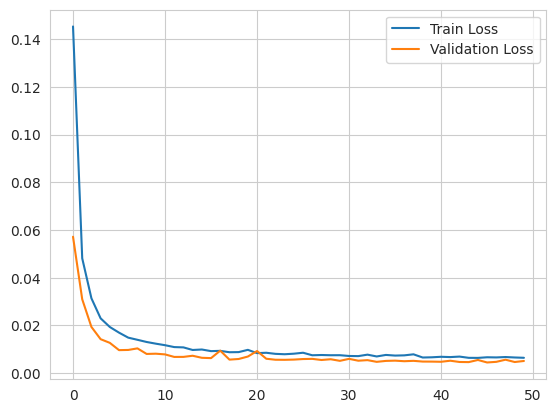

617/617 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
   Реальная стоимость  Предсказанная стоимость
0       375000.000000            376409.781250
1       321000.000000            325918.187500
2       118608.537600            117954.312500
3       143942.400000            138199.468750
4        66000.000000             63758.203125
5        95000.000000             91051.218750
6       143642.999808            142938.875000
7       408729.626726            409378.500000
8       148000.000000            148383.312500
9       186114.317315            189821.250000


In [ ]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()

# --- 7. Предсказание и обратное масштабирование ---
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)  # Возвращаем исходный масштаб

# Пример сравнения реальных и предсказанных значений
results = pd.DataFrame({
    'Реальная стоимость': scaler_y.inverse_transform(y_test).flatten(),
    'Предсказанная стоимость': y_pred.flatten()
})
print(results.head(10))

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred_scaled = model.predict(X_test)

y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_original = scaler_y.inverse_transform(y_test)

metrics = {
    "MAE (рубли)": mean_absolute_error(y_test_original, y_pred),
    "MSE (рубли²)": mean_squared_error(y_test_original, y_pred),
    "RMSE (рубли)": np.sqrt(mean_squared_error(y_test_original, y_pred)),
    "R²": r2_score(y_test_original, y_pred),

    # Метрики в масштабированном виде (для сравнения)
    "MAE (scaled)": mean_absolute_error(y_test, y_pred_scaled),
    "MSE (scaled)": mean_squared_error(y_test, y_pred_scaled),
}

for name, value in metrics.items():
    print(f"{name}: {value:.4f}")

617/617 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
MAE (рубли): 5318.8782
MSE (рубли²): 144892566.3201
RMSE (рубли): 12037.1328
R²: 0.9950
MAE (scaled): 0.0315
MSE (scaled): 0.0051


In [ ]:
X_test[0:2]

array([[[0.75      , 0.18181818, 0.06666667, ..., 0.        ,
         0.        , 0.        ]],

       [[0.        , 0.72727273, 0.73333333, ..., 0.        ,
         0.        , 0.        ]]])

In [ ]:
from tensorflow.keras.models import save_model

# Сохраняем с указанием custom_objects если есть свои метрики
save_model(
    model,
    'lstm_model.h5',
    save_format='h5',
    include_optimizer=True
)

In [ ]:
from tensorflow.keras.models import load_model
import pickle

# 1. Загружаем модель
model = load_model('lstm_model.h5')

# 2. Загружаем препроцессор
with open('preprocessor.pkl', 'rb') as f:
    preprocessor = pickle.load(f)

# 3. Загружаем scaler
with open('scaler_y.pkl', 'rb') as f:
    scaler_y = pickle.load(f)

# 4. Пример использования
def predict_cost(input_data):
    """Функция для предсказания"""
    X_processed = preprocessor.transform(input_data)
    X_reshaped = np.expand_dims(X_processed, axis=1)
    y_pred = model.predict(X_reshaped)
    return scaler_y.inverse_transform(y_pred)[0][0]

TypeError: Could not locate function 'mse'. Make sure custom classes are decorated with `@keras.saving.register_keras_serializable()`. Full object config: {'module': 'keras.metrics', 'class_name': 'function', 'config': 'mse', 'registered_name': 'mse'}

In [ ]:
import pandas as pd
import numpy as np

input_data = {
    'Год': [2016],
    'Месяц': [7],
    'День': [31],
    'Проходной балл': [0],
    'Бюджетные места': [5],
    'Программа': ['Инженерия данных'],
    'Вуз': ['Московский технический университет связи и информатики']
}

input_df = pd.DataFrame(input_data)

X_processed = preprocessor.transform(input_df)

# X_reshaped = np.expand_dims(X_processed, axis=1)

predicted_cost = model.predict(X_reshaped)
real_cost = scaler_y.inverse_transform(predicted_cost)[0][0]
print(f"Предсказанная стоимость: {real_cost:,.2f} руб.")

3083/3083 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
Предсказанная стоимость: 550,869.00 руб.


In [ ]:
X_processed

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 7 stored elements and shape (1, 1877)>

In [ ]:
import pandas as pd


unique_uni = df['Вуз'].unique()
print(unique_uni)

['Национальный исследовательский университет «Высшая школа экономики»'
 'Московский государственный лингвистический университет'
 'Московский технический университет связи и информатики'
 'Российский экономический университет имени Г.В. Плеханова'
 'Московский городской педагогический университет'
 'Государственный университет по землеустройству'
 'Московский государственный институт индустрии туризма имени Ю.А.Сенкевича'
 'Институт дистанционного и дополнительного образования Национального исследовательского университета «МЭИ»'
 'Московский технологический университет (МИРЭА, МГУПИ, МИТХТ)'
 'Московский государственный университет дизайна и технологии'
 'Российский новый университет' 'Институт бизнеса и дизайна'
 'Московский университет имени С.Ю. Витте'
 'Международный Университет в Москве'
 'Московский технологический институт'
 'Московский городской университет управления Правительства Москвы'
 'Институт государственного администрирования'
 'Российский государственный гуманитарный 

In [ ]:
connected_programs = df[df['Вуз'] == 'Московский технический университет связи и информатики']['Программа'].unique()

print("Программы МИРЭА — Российский технологический университет:")
for i, program in enumerate(sorted(connected_programs), 1):
    print(f"{i}. {program}")

Программы МИРЭА — Российский технологический университет:
1. Безопасность автоматизированных систем
2. Безопасность компьютерных систем
3. Беспроводная связь
4. Бизнес-аналитика и технологии цифровой экономики
5. Дата-аналитика и системы больших данных
6. Инженерия DevSecOps
7. Инженерия данных
8. Инженерия систем искусственного интеллекта
9. Организация и технологии защиты информации
10. Прикладная математика и программирование
11. Прикладные информационные системы
12. Промышленный интернет вещей и робототехника
13. Радиотехника и аудиовизуальные технологии
14. Разработка и программирование автономных робототехнических систем
15. Разработка и сопровождение программного обеспечения
16. Реклама и связи с общественностью в отрасли
17. Телекоммуникации: проектирование и эксплуатация сетей связи
18. Управление безопасностью телекоммуникационных систем и сетей


In [ ]:
df['Год'] = df['Дата архивации'].dt.year
df['Месяц'] = df['Дата архивации'].dt.month
df['Квартал'] = df['Дата архивации'].dt.quarter

# Лаговые признаки
df['Стоимость_lag1'] = df.groupby('Программа')['Стоимость'].shift(1)  # Значение за предыдущий месяц
df['Стоимость_lag12'] = df.groupby('Программа')['Стоимость'].shift(12)  # Для годовой сезонности

# Скользящее среднее
df['Стоимость_rolling_mean'] = df.groupby('Программа')['Стоимость'].transform(
    lambda x: x.rolling(window=3, min_periods=1).mean()
)

In [ ]:
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler

# Подготовка последовательностей
def create_sequences(data, n_steps):
    X, y = [], []
    for i in range(len(data) - n_steps):
        X.append(data[i:i+n_steps])
        y.append(data[i+n_steps])

    # Конвертируем в единый массив NumPy перед созданием тензора
    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32)

    return torch.FloatTensor(X), torch.FloatTensor(y)

# Нормализация данных
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[['Стоимость']])

# Создание последовательностей
n_steps = 12
X, y = create_sequences(scaled_data, n_steps)

train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Модель LSTM
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, output_size=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=64, num_layers=2, dropout=0.2)
        self.linear = nn.Linear(64, 1)

    def forward(self, x):
        x, _ = self.lstm(x)
        x = self.linear(x[:, -1, :])
        return x

model = LSTMModel()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-5)

# Обучение
for epoch in range(100):
    model.train()
    optimizer.zero_grad()
    y_pred = model(X_train)
    loss = criterion(y_pred, y_train)
    loss.backward()
    optimizer.step()
    print(f'Epoch {epoch}, Loss: {loss.item():.4f}')

Epoch 0, Loss: 0.3458
Epoch 1, Loss: 0.1348
Epoch 2, Loss: 0.0726
Epoch 3, Loss: 0.0473
Epoch 4, Loss: 0.0548
Epoch 5, Loss: 0.0545
Epoch 6, Loss: 0.0482
Epoch 7, Loss: 0.0451
Epoch 8, Loss: 0.0481
Epoch 9, Loss: 0.0485
Epoch 10, Loss: 0.0444
Epoch 11, Loss: 0.0426
Epoch 12, Loss: 0.0436
Epoch 13, Loss: 0.0439
Epoch 14, Loss: 0.0417
Epoch 15, Loss: 0.0385
Epoch 16, Loss: 0.0380
Epoch 17, Loss: 0.0389
Epoch 18, Loss: 0.0336
Epoch 19, Loss: 0.0337
Epoch 20, Loss: 0.0321
Epoch 21, Loss: 0.0406
Epoch 22, Loss: 0.0380
Epoch 23, Loss: 0.0421
Epoch 24, Loss: 0.0355
Epoch 25, Loss: 0.0304
Epoch 26, Loss: 0.0344
Epoch 27, Loss: 0.0380
Epoch 28, Loss: 0.0339
Epoch 29, Loss: 0.0306
Epoch 30, Loss: 0.0319
Epoch 31, Loss: 0.0341
Epoch 32, Loss: 0.0337
Epoch 33, Loss: 0.0309
Epoch 34, Loss: 0.0289
Epoch 35, Loss: 0.0297
Epoch 36, Loss: 0.0308
Epoch 37, Loss: 0.0290
Epoch 38, Loss: 0.0270
Epoch 39, Loss: 0.0279
Epoch 40, Loss: 0.0290
Epoch 41, Loss: 0.0276
Epoch 42, Loss: 0.0266
Epoch 43, Loss: 0.028

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
model.eval()
with torch.no_grad():
    test_pred = model(X_test)
    test_loss = criterion(test_pred, y_test)
print(f'Test MSE: {test_loss.item():.4f}')

# Денормализация
test_pred = scaler.inverse_transform(test_pred.numpy())
y_test_actual = scaler.inverse_transform(y_test.numpy())

# Визуализация
plt.plot(y_test_actual, label='Фактическая стоимость')
plt.plot(test_pred, label='Прогноз')
plt.legend()
plt.show()

mae = mean_absolute_error(y_test_actual, test_pred)
r2 = r2_score(y_test_actual, test_pred)

print(f'MAE: {mae:.2f} руб.')
print(f'R2 Score: {r2:.2f}')

AttributeError: 'Sequential' object has no attribute 'eval'

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# 1. Подготовка данных (адаптация под ваш существующий df)
def prepare_features(df, n_steps=12):
    """Создает временные признаки из вашего DataFrame"""
    # Создаем лаговые признаки
    for i in range(1, n_steps+1):
        df[f'lag_{i}'] = df['Стоимость'].shift(i)

    # Скользящие статистики
    df['rolling_mean_3'] = df['Стоимость'].rolling(3).mean()
    df['rolling_std_3'] = df['Стоимость'].rolling(3).std()

    # Удаляем пропуски
    df = df.dropna()

    # Выделяем фичи и таргет
    features = [col for col in df.columns if col.startswith('lag_') or col.startswith('rolling_')]
    X = df[features].values
    y = df['Стоимость'].values

    return X, y, features

# 2. Улучшенная LSTM модель с Dropout
class EnhancedLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=64, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True, num_layers=2, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.linear = nn.Linear(hidden_size, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_out = lstm_out[:, -1, :]  # Берем последний выход
        return self.linear(self.dropout(last_out))

# 3. Обучение модели на ваших данных
def train_lstm_model(df, epochs=300):
    # Подготовка данных
    X, y, feature_names = prepare_features(df)
    print(f"Используемые признаки: {feature_names}")

    # Нормализация
    scaler = MinMaxScaler()
    X = scaler.fit_transform(X)
    y = y.reshape(-1, 1)

    # Формирование последовательностей
    X = X.reshape(-1, 1, len(feature_names))  # [samples, timesteps, features]

    # Разделение на train/test (80/20)
    split_idx = int(0.8 * len(X))
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]

    # Конвертация в тензоры PyTorch
    X_train = torch.FloatTensor(X_train)
    y_train = torch.FloatTensor(y_train)
    X_test = torch.FloatTensor(X_test)
    y_test = torch.FloatTensor(y_test)

    # Инициализация модели
    model = EnhancedLSTM(input_size=len(feature_names))
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=15, verbose=True)

    # Обучение
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()
        scheduler.step(loss)

        if epoch % 30 == 0:
            print(f'Epoch {epoch}: Loss = {loss.item():.6f}')

    # Оценка
    model.eval()
    with torch.no_grad():
        test_pred = model(X_test)
        test_loss = criterion(test_pred, y_test)
        mae = nn.L1Loss()(test_pred, y_test)

        # Денормализация для интерпретации
        test_pred = test_pred.numpy().flatten()
        y_test = y_test.numpy().flatten()

        # Расчет R^2
        ss_res = np.sum((y_test - test_pred)**2)
        ss_tot = np.sum((y_test - np.mean(y_test))**2)
        r2 = 1 - (ss_res / ss_tot)

    print(f"\nРезультаты на тестовых данных:")
    print(f"- MSE: {test_loss.item():.6f}")
    print(f"- MAE: {mae.item():.2f} руб.")
    print(f"- R²: {r2:.4f}")

    # Визуализация
    plt.figure(figsize=(12, 6))
    plt.plot(y_test, label='Фактические значения', alpha=0.7)
    plt.plot(test_pred, label='Прогноз LSTM', linestyle='--')
    plt.title(f'Прогноз vs Факт (MAE: {mae.item():.0f} руб., R²: {r2:.2f})')
    plt.xlabel('Временные периоды')
    plt.ylabel('Стоимость обучения')
    plt.legend()
    plt.grid(True)
    plt.show()

    return model

# Пример использования с вашим DataFrame
if __name__ == "__main__":
    # Ваш уже очищенный DataFrame df должен содержать колонку 'Стоимость'
    model = train_lstm_model(df)


Используемые признаки: ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'lag_8', 'lag_9', 'lag_10', 'lag_11', 'lag_12', 'rolling_mean_3', 'rolling_std_3']


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 0: Loss = 88935227392.000000
Epoch 30: Loss = 88935137280.000000
Epoch 60: Loss = 88935120896.000000


KeyboardInterrupt: 